# 07 — Master Data Feature Selection

**Goal:** Systematically reduce the `master_data_ml_preprocessed` table to a
meaningful, interpretable set of feature groups ready for use in `model_configs.py`.

**Workflow:**
1. Load the full gold dataset and inventory all columns
2. Separate structural columns from ML features
3. Remove near-zero-variance features (no signal)
4. Rank features by correlation with the target (sick leave %)
5. Remove redundant inter-correlated features
6. Propose named feature groups for `FEATURE_CATALOG` in `model_configs.py`

**Output:** Ready-to-paste `FEATURE_CATALOG` entries printed in the final cell.

In [18]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.feature_selection import VarianceThreshold

# Make src/ importable from notebook context
PROJECT_ROOT = Path().resolve().parent.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import DIR_DB_GOLD, ML_TARGET_COLUMN

# ── Plot style ─────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.0)
plt.rcParams["figure.dpi"] = 110

# ── Structural columns — never treated as ML features ──────────────────────
STRUCTURAL_COLS = {"silver_id", "quarter", "year", "period_enddate", "BedrijfstakkenBranchesSBI2008"}

print(f"Project root : {PROJECT_ROOT}")
print(f"Gold DB      : {DIR_DB_GOLD}")
print(f"Target column: {ML_TARGET_COLUMN}")

Project root : C:\Users\Yanni\Github\EAISI\eaisi-uwv
Gold DB      : C:\Users\Yanni\Github\EAISI\eaisi-uwv\data\3_gold\gold_data.db
Target column: Ziekteverzuimpercentage_1


---
## 1 — Load the Gold Dataset

In [19]:
from src.ml_engineering.ml_1_data_extraction import DataExtractor

extractor = DataExtractor(db_path=DIR_DB_GOLD, table_name="master_data_ml_preprocessed")
df_raw = extractor.extract(target_column=ML_TARGET_COLUMN, feature_groups=None)  # discovery: all columns

print(f"Shape: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")
df_raw.head(3)

✅ Extraction complete | mode=discovery | features=439 | rows=4641


Shape: 4641 rows × 441 columns


,period_enddate,Ziekteverzuimpercentage_1,year,quarter,trend_index,BedrijfskenmerkenSBI2008_300003,BedrijfskenmerkenSBI2008_300007,BedrijfskenmerkenSBI2008_300013,BedrijfskenmerkenSBI2008_301000,BedrijfskenmerkenSBI2008_305700,...,GewerkteUren_5_A045285,GewerkteUren_5_A045286,WerkzamePersonenSeizoengecorrigeerd_2_A045285,WerkzamePersonenSeizoengecorrigeerd_2_A045286,WerkzamePersonenSeizoengecorrigeerd_9_A045285,WerkzamePersonenSeizoengecorrigeerd_9_A045286,WerkzamePersonen_1_A045285,WerkzamePersonen_1_A045286,WerkzamePersonen_7_A045285,WerkzamePersonen_7_A045286
0,1996-03-31 00:00:00.000000,5.5,1996.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,216.866667,44.733333,589.733333,102.6,0.8,-0.066667,582.933333,102.0,13.2,0.733333
1,1996-03-31 00:00:00.000000,6.2,1996.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,216.866667,44.733333,589.733333,102.6,0.8,-0.066667,582.933333,102.0,13.2,0.733333
2,1996-03-31 00:00:00.000000,6.6,1996.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,216.866667,44.733333,589.733333,102.6,0.8,-0.066667,582.933333,102.0,13.2,0.733333


---
## 2 — Column Inventory

Classify every column into one of five buckets:
- **structural** — date / key columns that are never ML features
- **target** — the dependent variable
- **sector_filter** — OHE columns (`BedrijfskenmerkenSBI2008_*`) used to select a specific sector for prediction, not features
- **continuous** — genuine numeric predictors

In [20]:
SBI_FILTER_PREFIX = "BedrijfskenmerkenSBI2008_"

structural    = [c for c in df_raw.columns if c in STRUCTURAL_COLS]
target_col    = [ML_TARGET_COLUMN]
sector_filter = [c for c in df_raw.columns if c.startswith(SBI_FILTER_PREFIX)]

# Feature columns: everything else — exclude structural, target, and sector-filter OHE
feature_cols  = [
    c for c in df_raw.columns
    if c not in STRUCTURAL_COLS
    and c != ML_TARGET_COLUMN
    and not c.startswith(SBI_FILTER_PREFIX)
]

summary = pd.DataFrame({
    "Bucket":  ["structural", "target", "sector_filter (OHE)", "feature"],
    "Count":   [len(structural), len(target_col), len(sector_filter), len(feature_cols)],
    "Examples": [
        ", ".join(structural[:3]),
        ML_TARGET_COLUMN,
        ", ".join(sector_filter[:3]),
        ", ".join(feature_cols[:3]),
    ],
})
print(summary.to_string(index=False))
print(f"\nTotal ML features (excl. structural + target + sector_filter): {len(feature_cols)}")

example_col = sector_filter[0] if sector_filter else "BedrijfskenmerkenSBI2008_XXX"
print(f"\nSector filter columns ({len(sector_filter)}) — use to restrict analysis to one SBI sector:")
print(f"  e.g. df_raw[df_raw[{example_col!r}] == 1]")

             Bucket  Count                                                                                          Examples
         structural      3                                                                     period_enddate, year, quarter
             target      1                                                                         Ziekteverzuimpercentage_1
sector_filter (OHE)     39 BedrijfskenmerkenSBI2008_300003, BedrijfskenmerkenSBI2008_300007, BedrijfskenmerkenSBI2008_300013
            feature    398                         trend_index, AdemtGeenStoffenIn_24_MBG0095, AdemtGeenStoffenIn_24_MOG0095

Total ML features (excl. structural + target + sector_filter): 398

Sector filter columns (39) — use to restrict analysis to one SBI sector:
  e.g. df_raw[df_raw['BedrijfskenmerkenSBI2008_300003'] == 1]


In [21]:
# Full column name listing — sorted, so you can scan for naming patterns
print("=== ALL FEATURE COLUMNS ===")
for i, col in enumerate(sorted(feature_cols), 1):
    print(f"{i:>4}. {col}")

=== ALL FEATURE COLUMNS ===
   1. AdemtGeenStoffenIn_24_MBG0095
   2. AdemtGeenStoffenIn_24_MOG0095
   3. AdemtGeenStoffenIn_24_MW00000
   4. AdemtStoffenIn_20_MBG0095
   5. AdemtStoffenIn_20_MOG0095
   6. AdemtStoffenIn_20_MW00000
   7. Arbeidsjaren_20
   8. Arbeidsjaren_25
   9. Arbeidsjaren_3_3000_A045285
  10. Arbeidsjaren_3_3000_A045286
  11. Arbeidsjaren_3_4000_A045285
  12. Arbeidsjaren_3_4000_A045286
  13. BanenSeizoengecorrigeerd_10_A045285
  14. BanenSeizoengecorrigeerd_10_A045286
  15. BanenSeizoengecorrigeerd_4_A045285
  16. BanenSeizoengecorrigeerd_4_A045286
  17. Banen_2_3000_A045285
  18. Banen_2_3000_A045286
  19. Banen_2_4000_A045285
  20. Banen_2_4000_A045286
  21. Banen_2_A045285_3000
  22. Banen_2_A045285_4000
  23. Banen_2_A045286_3000
  24. Banen_2_A045286_4000
  25. Banen_3_A045285
  26. Banen_3_A045286
  27. Banen_7_A045285_3000
  28. Banen_7_A045285_4000
  29. Banen_7_A045286_3000
  30. Banen_7_A045286_4000
  31. Banen_8_A045285
  32. Banen_8_A045286
  33. Belo

---
## 3 — Missing Value Audit

`master_data_ml_preprocessed` is post-imputation so there should be zero nulls.
This cell confirms that — any non-zero value here signals a pipeline issue.

In [22]:
null_counts = df_raw[feature_cols].isnull().sum()
cols_with_nulls = null_counts[null_counts > 0]

if cols_with_nulls.empty:
    print("✅ Zero nulls across all feature columns.")
else:
    print(f"⚠️  {len(cols_with_nulls)} columns still contain nulls:")
    print(cols_with_nulls.sort_values(ascending=False).head(20))

✅ Zero nulls across all feature columns.


---
## 4 — Variance Filter

Features with near-zero variance carry no signal. A variance of 0 means the column is constant;
a very low variance (e.g. < 0.01) means almost no variation across observations.

**Adjust `VAR_THRESHOLD` below and re-run to see the effect on feature count.**

In [23]:
VAR_THRESHOLD = 0.001   # ← adjust this
# Rationale: CBS features are ratios/rates bounded in narrow ranges (e.g. 0.02–0.08).
# Their variance is inherently small. 0.001 removes only truly constant or near-constant
# columns without discarding meaningful compact variation. Use the histogram below to verify.

X_all = df_raw[feature_cols].copy()

selector_var = VarianceThreshold(threshold=VAR_THRESHOLD)
selector_var.fit(X_all)
mask_var = selector_var.get_support()

removed_var    = [c for c, keep in zip(feature_cols, mask_var) if not keep]
kept_after_var = [c for c, keep in zip(feature_cols, mask_var) if keep]

print(f"Variance threshold : {VAR_THRESHOLD}")
print(f"Features before    : {len(feature_cols)}")
print(f"Removed            : {len(removed_var)}")
print(f"Remaining          : {len(kept_after_var)}")

print(f"\nRemoved columns (sample):")
for c in sorted(removed_var)[:20]:
    print(f"  {c:60s}  var={X_all[c].var():.6f}")

Variance threshold : 0.001
Features before    : 398
Removed            : 0
Remaining          : 398

Removed columns (sample):


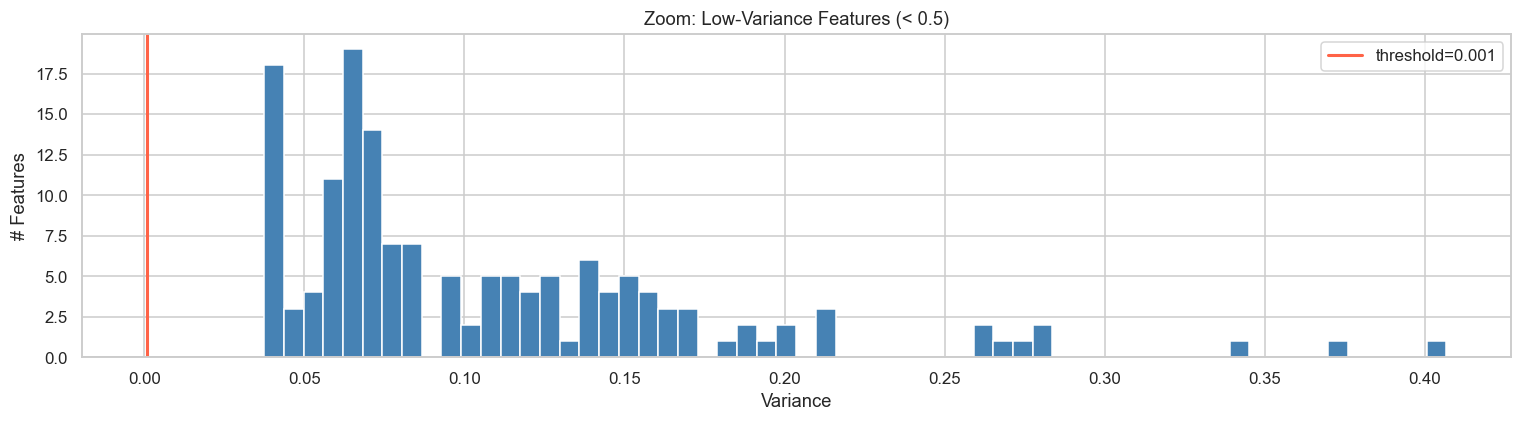

In [37]:
# Distribution of variance values — helps choose the right threshold
variances = X_all.var().sort_values()

fig, ax = plt.subplots(figsize=(14, 4))

ax.hist(variances[variances < 0.5], bins=60, color="steelblue", edgecolor="white")
ax.axvline(VAR_THRESHOLD, color="tomato", linewidth=2, label=f"threshold={VAR_THRESHOLD}")
ax.set_title("Zoom: Low-Variance Features (< 0.5)")
ax.set_xlabel("Variance")
ax.set_ylabel("# Features")
ax.legend()

plt.tight_layout()
plt.show()

---
## 5 — Target Correlation Analysis

Rank every surviving feature by its Pearson correlation with `Ziekteverzuimpercentage_1`.
High |r| = strong linear relationship with sick leave. Low |r| = weak predictor.

Use `TOP_N` to control how many features to display.

In [39]:
TOP_N = 15   # ← adjust this

X_var = df_raw[kept_after_var]
y     = df_raw[ML_TARGET_COLUMN]

target_corr = (
    X_var
    .corrwith(y)
    .dropna()
    .rename("pearson_r")
    .to_frame()
    .assign(abs_r=lambda d: d["pearson_r"].abs())
    .sort_values("abs_r", ascending=False)
)

print(f"Features after variance filter : {len(X_var.columns)}")
print(f"\nTop {TOP_N} features by |Pearson r| with target:")
print(target_corr.head(TOP_N).to_string())

Features after variance filter : 398

Top 15 features by |Pearson r| with target:
                                 pearson_r     abs_r
GewerkteUren_3_A045285_4000       0.348553  0.348553
WerkzamePersonen_6_A045285_3000   0.320605  0.320605
Banen_7_A045285_3000              0.318117  0.318117
Banen_7_A045285_4000              0.315756  0.315756
WerkzamePersonen_6_A045285_4000   0.313139  0.313139
BeloningVanWerknemers_5           0.311647  0.311647
GewerkteUren_8_A045285_4000       0.308251  0.308251
GewerkteUren_3_A045285_3000       0.305856  0.305856
Banen_2_A045285_4000              0.305403  0.305403
WerkzamePersonen_1_A045285_4000   0.304960  0.304960
Banen_7_A045286_3000              0.303948  0.303948
Banen_2_A045286_4000              0.302786  0.302786
Loonkosten_7                      0.302533  0.302533
Banen_7_A045286_4000              0.301014  0.301014
Lonen_6                           0.300580  0.300580


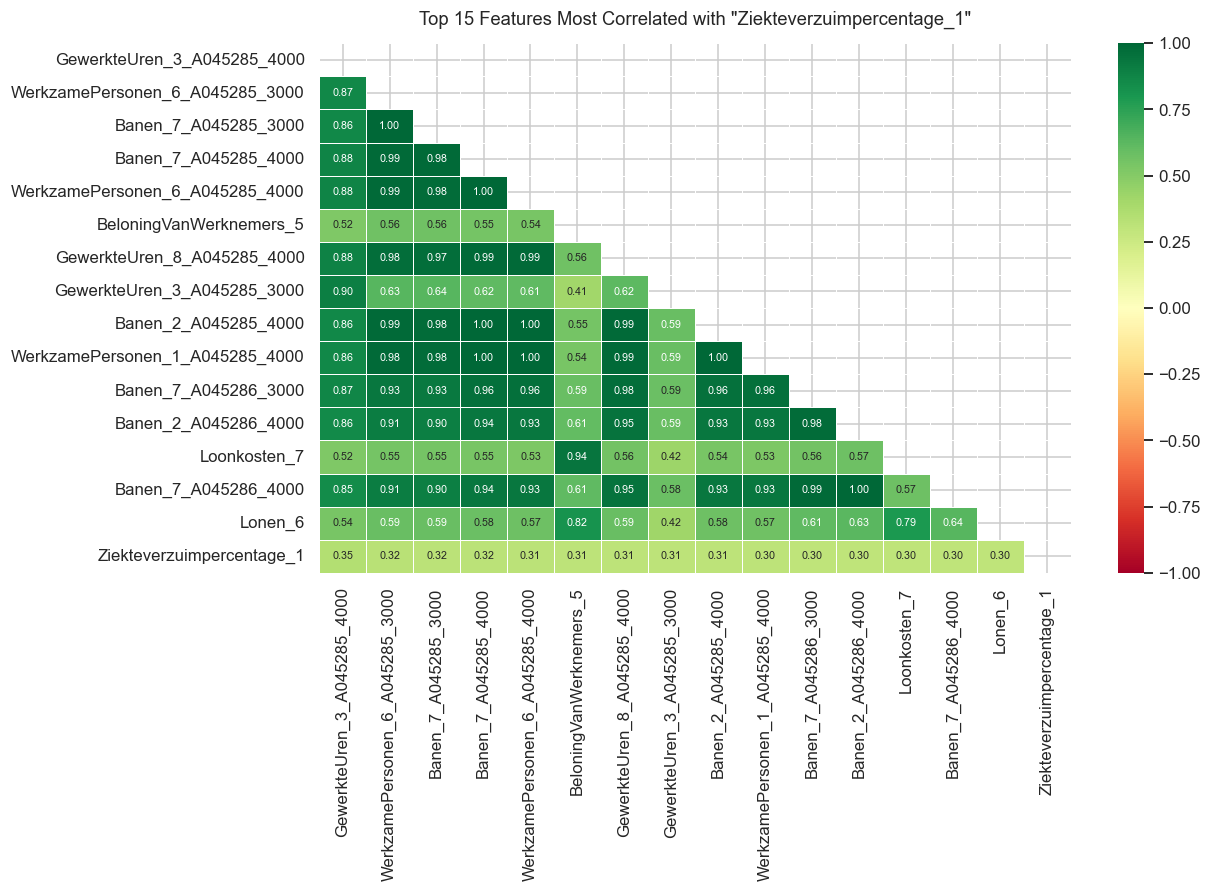

In [40]:
import polars as pl
import polars.selectors as cs


def plot_corr_n_strongest(df: pd.DataFrame, y: str, n: int = 10):
    """
    Plots a lower-triangle heatmap of the n features with the strongest
    absolute correlation to the target variable y, revealing both how each
    feature relates to the target and how the top features relate to each other.

    Args:
        df  : Pandas DataFrame containing numeric features + the target column.
        y   : Name of the target column.
        n   : Number of top features (excluding the target itself) to display.
    """
    # Convert to Polars and restrict to numeric columns
    df_pl = pl.from_pandas(df).select(cs.numeric())
    df_pl = df_pl.with_columns(pl.all().cast(pl.Float64, strict=False))

    if y not in df_pl.columns:
        raise KeyError(f"Target column {y!r} not found. Available: {df_pl.columns}")

    # Full correlation matrix
    corr_matrix = df_pl.corr()
    feature_names = corr_matrix.columns
    corr_vals = corr_matrix[y].to_list()

    # Select top n features by |corr with y| (exclude target itself)
    corr_with_y = (
        pl.DataFrame({"feature": feature_names, "corr": corr_vals})
        .drop_nans()
        .filter(pl.col("feature") != y)
        .with_columns(pl.col("corr").abs().alias("abs_corr"))
        .sort("abs_corr", descending=True)
        .head(n)
    )
    top_n_features = corr_with_y.get_column("feature").to_list()

    # Filtered correlation matrix: top features + target
    cols_to_plot = top_n_features + [y]
    df_corr_pd = df_pl.select(cols_to_plot).corr().to_pandas()
    df_corr_pd.index = df_corr_pd.columns

    mask = np.triu(np.ones_like(df_corr_pd, dtype=bool))

    fig, ax = plt.subplots(figsize=(11.7, 8.27))
    sns.heatmap(
        ax=ax,
        data=df_corr_pd,
        mask=mask,
        annot=True,
        fmt=".2f",
        cmap="RdYlGn",
        vmin=-1, vmax=1,
        center=0,
        linewidths=0.5,
        annot_kws={"size": 7},
    )
    ax.set_title(f"Top {n} Features Most Correlated with \"{y}\"", pad=12)
    plt.tight_layout()
    plt.show()


plot_corr_n_strongest(
    df_raw[kept_after_var + [ML_TARGET_COLUMN]],
    y=ML_TARGET_COLUMN,
    n=TOP_N,
)

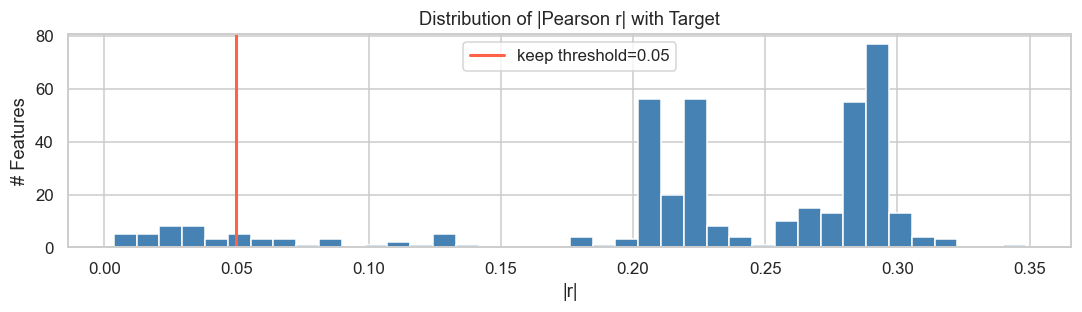

Features with |r| ≥ 0.05: 367


In [27]:
# Distribution of |r| values — helps choose a minimum correlation cutoff
CORR_KEEP_THRESHOLD = 0.05   # ← adjust this
# Rationale: In quarterly macroeconomic aggregates, individual predictors rarely exceed r=0.3
# with the target due to sector heterogeneity and aggregation smoothing. Cutting at 0.1
# discards features that are weak individually but meaningful in combination. The redundancy
# filter (Step 6) removes collinear duplicates, so being inclusive here costs nothing.

fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(target_corr["abs_r"], bins=40, color="steelblue", edgecolor="white")
ax.axvline(CORR_KEEP_THRESHOLD, color="tomato", linewidth=2,
           label=f"keep threshold={CORR_KEEP_THRESHOLD}")
ax.set_title("Distribution of |Pearson r| with Target")
ax.set_xlabel("|r|")
ax.set_ylabel("# Features")
ax.legend()
plt.tight_layout()
plt.show()

features_above_corr = target_corr[target_corr["abs_r"] >= CORR_KEEP_THRESHOLD].index.tolist()
print(f"Features with |r| ≥ {CORR_KEEP_THRESHOLD}: {len(features_above_corr)}")

---
## 6 — Inter-Feature Correlation (Redundancy Removal)

When two features are highly correlated with each other, they provide redundant information.
We keep the one with the higher target correlation and drop the other.

**Adjust `REDUNDANCY_THRESHOLD` to control aggressiveness.**

In [28]:
REDUNDANCY_THRESHOLD = 0.90   # ← adjust: drop one of any pair with |r| >= this

# Work on features that passed the target-correlation filter
X_corr_pool = df_raw[features_above_corr]

corr_matrix = X_corr_pool.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# For each highly-correlated pair, drop the one with LOWER target correlation
to_drop_redundant = set()
for col in upper_tri.columns:
    partners = upper_tri.index[upper_tri[col] >= REDUNDANCY_THRESHOLD].tolist()
    for partner in partners:
        # Keep whichever has higher |r| with target
        r_col     = target_corr.loc[col, "abs_r"]     if col in target_corr.index     else 0
        r_partner = target_corr.loc[partner, "abs_r"] if partner in target_corr.index else 0
        to_drop_redundant.add(col if r_col < r_partner else partner)

kept_after_redundancy = [c for c in features_above_corr if c not in to_drop_redundant]

print(f"Features entering redundancy filter : {len(features_above_corr)}")
print(f"Dropped as redundant (|r|≥{REDUNDANCY_THRESHOLD}) : {len(to_drop_redundant)}")
print(f"Remaining                           : {len(kept_after_redundancy)}")

Features entering redundancy filter : 367
Dropped as redundant (|r|≥0.9) : 339
Remaining                           : 28


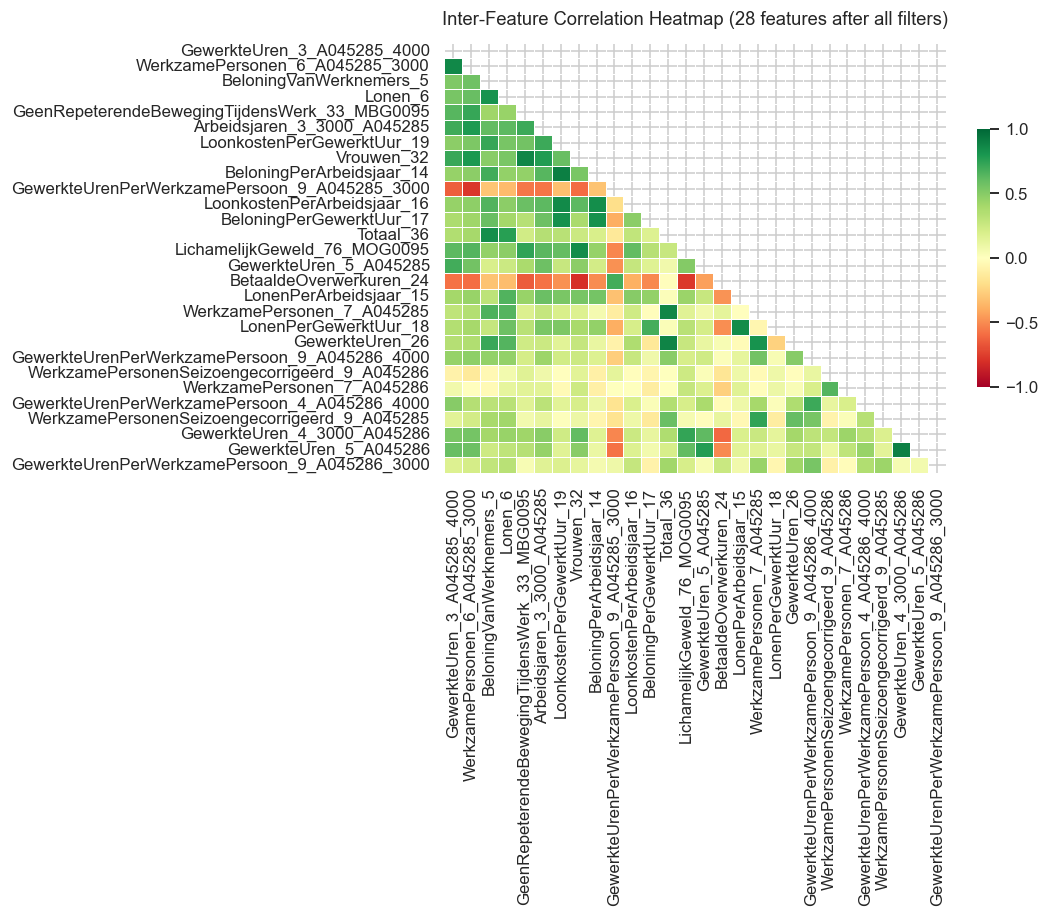

In [42]:
# Correlation heatmap of the surviving features (consistent with plot_corr_n_strongest)
n = len(kept_after_redundancy)

if n <= 60:
    df_pl = pl.from_pandas(df_raw[kept_after_redundancy]).with_columns(
        pl.all().cast(pl.Float64, strict=False)
    )
    corr_final = df_pl.corr().to_pandas()
    corr_final.index = corr_final.columns

    mask = np.triu(np.ones_like(corr_final, dtype=bool))
    fig_size = max(10, n * 0.35)

    fig, ax = plt.subplots(figsize=(fig_size, fig_size * 0.85))
    sns.heatmap(
        ax=ax,
        data=corr_final,
        mask=mask,
        annot=(n <= 20),
        fmt=".2f",
        cmap="RdYlGn",
        vmin=-1, vmax=1,
        center=0,
        linewidths=0.5,
        annot_kws={"size": 7},
        cbar_kws={"shrink": 0.6},
    )
    ax.set_title(f"Inter-Feature Correlation Heatmap ({n} features after all filters)", pad=12)
    plt.tight_layout()
    plt.show()
else:
    print(f"{n} features remaining — heatmap skipped (too dense). Lower REDUNDANCY_THRESHOLD to reduce further.")

---
## 7 — Reduction Summary

Shows how many features survived each filter step.

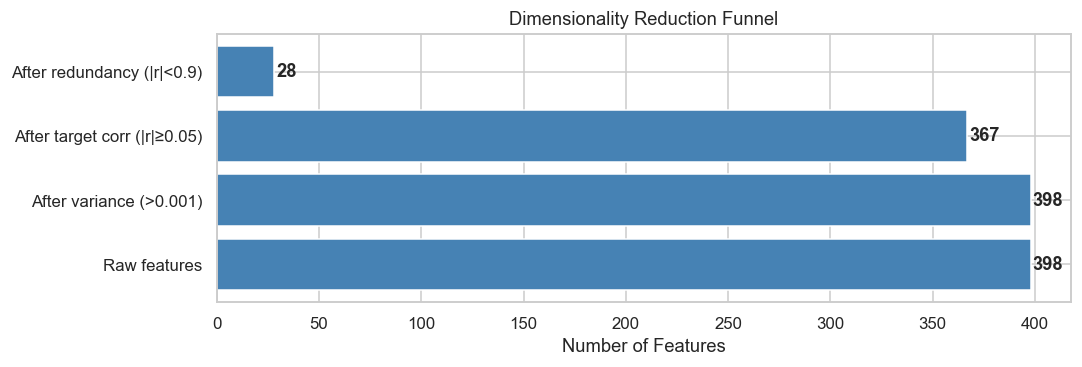


Final surviving features:
  1. Arbeidsjaren_3_3000_A045285                                   r=+0.294
  2. BeloningPerArbeidsjaar_14                                     r=+0.265
  3. BeloningPerGewerktUur_17                                      r=+0.237
  4. BeloningVanWerknemers_5                                       r=+0.312
  5. BetaaldeOverwerkuren_24                                       r=-0.220
  6. GeenRepeterendeBewegingTijdensWerk_33_MBG0095                 r=+0.298
  7. GewerkteUrenPerWerkzamePersoon_4_A045286_4000                 r=+0.115
  8. GewerkteUrenPerWerkzamePersoon_9_A045285_3000                 r=-0.258
  9. GewerkteUrenPerWerkzamePersoon_9_A045286_3000                 r=+0.068
 10. GewerkteUrenPerWerkzamePersoon_9_A045286_4000                 r=+0.134
 11. GewerkteUren_26                                               r=+0.185
 12. GewerkteUren_3_A045285_4000                                   r=+0.349
 13. GewerkteUren_4_3000_A045286                             

In [43]:
steps = [
    ("Raw features",                    len(feature_cols)),
    (f"After variance (>{VAR_THRESHOLD})",         len(kept_after_var)),
    (f"After target corr (|r|≥{CORR_KEEP_THRESHOLD})", len(features_above_corr)),
    (f"After redundancy (|r|<{REDUNDANCY_THRESHOLD})",  len(kept_after_redundancy)),
]

labels, counts = zip(*steps)

fig, ax = plt.subplots(figsize=(10, 3.5))
bars = ax.barh(range(len(labels)), counts, color="steelblue", edgecolor="white")
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel("Number of Features")
ax.set_title("Dimensionality Reduction Funnel")
for bar, count in zip(bars, counts):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            str(count), va="center", fontweight="bold")
plt.tight_layout()
plt.show()

print("\nFinal surviving features:")
for i, col in enumerate(sorted(kept_after_redundancy), 1):
    r = target_corr.loc[col, "pearson_r"] if col in target_corr.index else float("nan")
    print(f"{i:>3}. {col:60s}  r={r:+.3f}")

---
## 8 — Feature Group Assignment

Manually assign surviving features to named groups. These groups map directly to `FEATURE_CATALOG`
entries in `model_configs.py`.

**Edit the dictionary below, re-run, and the final cell will print ready-to-paste Python code.**

In [44]:
# ── EDIT THIS CELL ──────────────────────────────────────────────────────────
PROPOSED_GROUPS = {
    "compensation": {
        "columns": [
            "BeloningVanWerknemers_5",
            "BeloningPerArbeidsjaar_14",
            "BeloningPerGewerktUur_17",
            "Lonen_6",
            "LonenPerArbeidsjaar_15",
            "LonenPerGewerktUur_18",
            "LoonkostenPerArbeidsjaar_16",
            "LoonkostenPerGewerktUur_19",
        ],
        "source_table": "83415NED",
        "description": "Wage and labour cost indicators per worker, per hour and in total.",
    },
    "labor_volume": {
        "columns": [
            "Arbeidsjaren_3_3000_A045285",
            "BetaaldeOverwerkuren_24",
            "GewerkteUren_26",
            "GewerkteUren_3_A045285_4000",
            "GewerkteUren_4_3000_A045286",
            "GewerkteUren_5_A045285",
            "GewerkteUren_5_A045286",
            "GewerkteUrenPerWerkzamePersoon_4_A045286_4000",
            "GewerkteUrenPerWerkzamePersoon_9_A045285_3000",
            "GewerkteUrenPerWerkzamePersoon_9_A045286_3000",
            "GewerkteUrenPerWerkzamePersoon_9_A045286_4000",
        ],
        "source_table": "83415NED",
        "description": "Hours worked and overtime by sector and employee category.",
    },
    "workforce": {
        "columns": [
            "Totaal_36",
            "Vrouwen_32",
            "WerkzamePersonen_6_A045285_3000",
            "WerkzamePersonen_7_A045285",
            "WerkzamePersonen_7_A045286",
            "WerkzamePersonenSeizoengecorrigeerd_9_A045285",
            "WerkzamePersonenSeizoengecorrigeerd_9_A045286",
        ],
        "source_table": "83415NED",
        "description": "Number of employed persons, seasonally adjusted, by gender and category.",
    },
    "working_conditions": {
        "columns": [
            "GeenRepeterendeBewegingTijdensWerk_33_MBG0095",
            "LichamelijkGeweld_76_MOG0095",
        ],
        "source_table": "83157NED",
        "description": "NEA survey indicators: repetitive movement absence and physical violence at work.",
    },
}
# ── END EDIT ────────────────────────────────────────────────────────────────

assigned   = {col for g in PROPOSED_GROUPS.values() for col in g["columns"]}
unassigned = [c for c in kept_after_redundancy if c not in assigned]
unknown_assigned = [c for c in assigned if c not in kept_after_redundancy]

print(f"Surviving features   : {len(kept_after_redundancy)}")
print(f"Assigned to groups   : {len(assigned)}")
print(f"Unassigned           : {len(unassigned)}")

if unassigned:
    print("\n── Unassigned features ──")
    for c in sorted(unassigned):
        r = target_corr.loc[c, "pearson_r"] if c in target_corr.index else float("nan")
        print(f"  {c:60s}  r={r:+.3f}")

if unknown_assigned:
    print("\n⚠️  Columns in PROPOSED_GROUPS not in surviving features:")
    for c in sorted(unknown_assigned):
        print(f"  {c}")

Surviving features   : 28
Assigned to groups   : 28
Unassigned           : 0


---
## 9 — Scatter: Top Features vs Target

Quick visual sanity check — does the relationship look sensible?

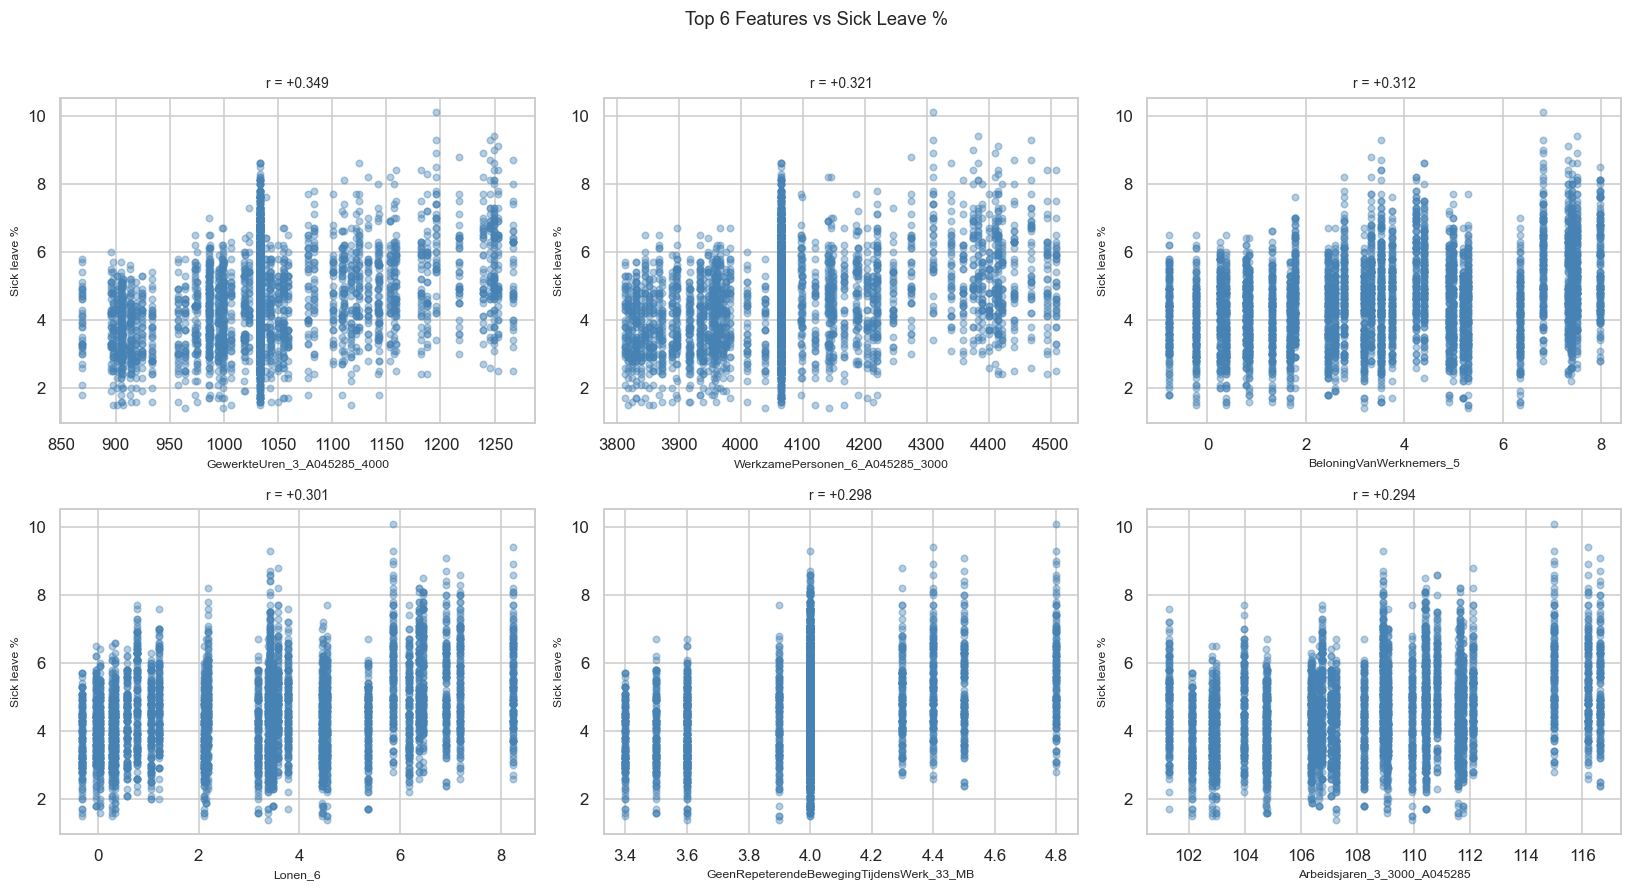

In [45]:
SCATTER_TOP_N = 6   # ← adjust: number of top-correlated features to plot

top_features = target_corr[target_corr.index.isin(kept_after_redundancy)].head(SCATTER_TOP_N).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, feat in zip(axes, top_features):
    r = target_corr.loc[feat, "pearson_r"]
    ax.scatter(df_raw[feat], df_raw[ML_TARGET_COLUMN], alpha=0.4, s=18, color="steelblue")
    ax.set_xlabel(feat[:40], fontsize=8)
    ax.set_ylabel("Sick leave %", fontsize=8)
    ax.set_title(f"r = {r:+.3f}", fontsize=9)

for ax in axes[len(top_features):]:
    ax.set_visible(False)

plt.suptitle(f"Top {SCATTER_TOP_N} Features vs Sick Leave %", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

---
## 10 — Generate FEATURE_CATALOG Code

Run this cell after completing Section 8 to get ready-to-paste Python code
for `FEATURE_CATALOG` in `src/ml_engineering/model_configs.py`.

In [46]:
def _fmt_list(cols, indent=12):
    """Format a list of strings as an indented Python list literal."""
    if not cols:
        return "[]"
    pad = " " * indent
    inner = f",\n{pad}".join(f'"{c}"' for c in cols)
    return f"[\n{pad}{inner},\n{' ' * (indent - 4)}]"


lines = ["FEATURE_CATALOG: Dict[str, FeatureGroup] = {"]

for group_name, meta in PROPOSED_GROUPS.items():
    cols_fmt = _fmt_list(meta["columns"])
    lines += [
        f'    "{group_name}": FeatureGroup(',
        f'        name="{group_name}",',
        f'        columns={cols_fmt},',
        f'        source_table="{meta["source_table"]}",',
        f'        description="{meta["description"]}",',
        f'    ),',
    ]

lines.append("}")

output = "\n".join(lines)
print("=" * 70)
print("Paste the following into model_configs.py (replace FEATURE_CATALOG):")
print("=" * 70)
print(output)

Paste the following into model_configs.py (replace FEATURE_CATALOG):
FEATURE_CATALOG: Dict[str, FeatureGroup] = {
    "compensation": FeatureGroup(
        name="compensation",
        columns=[
            "BeloningVanWerknemers_5",
            "BeloningPerArbeidsjaar_14",
            "BeloningPerGewerktUur_17",
            "Lonen_6",
            "LonenPerArbeidsjaar_15",
            "LonenPerGewerktUur_18",
            "LoonkostenPerArbeidsjaar_16",
            "LoonkostenPerGewerktUur_19",
        ],
        source_table="83415NED",
        description="Wage and labour cost indicators per worker, per hour and in total.",
    ),
    "labor_volume": FeatureGroup(
        name="labor_volume",
        columns=[
            "Arbeidsjaren_3_3000_A045285",
            "BetaaldeOverwerkuren_24",
            "GewerkteUren_26",
            "GewerkteUren_3_A045285_4000",
            "GewerkteUren_4_3000_A045286",
            "GewerkteUren_5_A045285",
            "GewerkteUren_5_A045286",
     